# Hydrovoltaic ML – Phase 1 Clean Modeling Notebook

This notebook summarizes the Phase 1 modeling workflow for the curated hydrovoltaic dataset.

Main goals:
- build and compare early interpretable ML models
- evaluate target definition choices
- diagnose key confounding effects
- identify the dominant mechanism-related variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import shap

## Load cleaned dataset

In [3]:
df_clean = pd.read_csv("hydrovoltaic_clean.csv")

In [4]:
df_clean.shape

(183, 43)

In [5]:
df_clean.columns.tolist()

['paper_doi',
 'review_covered',
 'ref_year',
 'device_structure',
 'built_in_asymmetry',
 'asymmetry_origin',
 'primary_mobile_ion',
 'secondary_ion_present',
 'secondary_mobile_ion',
 'ion_origin',
 'auxiliary_redox_present',
 'continuous_output',
 'water_interaction_mode',
 'rh_percent',
 'inorganic_electrolyte_present',
 'inorganic_electrolyte_type',
 'inorganic_electrolyte_concentration_wt%',
 'polyelectrolyte_present',
 'active_material_raw',
 'material_class',
 'structure_class',
 'ionic_groups',
 'top_electrode',
 'bottom_electrode',
 'electrode_symmetry',
 'metal_electrode',
 'voc_V',
 'jsc_uA_cm2',
 'power_density_uW_cm2',
 'internal_resistance_MΩ',
 'output_timescale_class',
 'stability_time_min',
 'dominant_mechanism',
 'has_anionic',
 'has_cationic',
 'has_zwitterionic',
 'polyelectrolyte_anionic_raw',
 'polyelectrolyte_cationic_raw',
 'polyelectrolyte_zwitterionic_raw',
 'has_any_polyelectrolyte',
 'estimated_power_density_uW_cm2',
 'log_estimated_power_density',
 'ion_ty

In [6]:
df_clean[["voc_V", "jsc_uA_cm2", "power_density_uW_cm2"]].describe()

,voc_V,jsc_uA_cm2,power_density_uW_cm2
count,183.000000,159.000000,116.000000
mean,0.821087,67.050881,24.577668
std,0.833232,302.003796,143.954829
min,0.019000,0.003000,0.000360
25%,0.355000,0.375000,0.077500
50%,0.610000,4.000000,0.870000
75%,0.925000,21.900000,8.025000
max,5.000000,3000.000000,1500.000000


## Feature engineering for Phase 1

In [8]:
# Preserve structured polyelectrolyte indicators
df_clean["has_anionic"] = df_clean["polyelectrolyte_anionic_raw"].notna().astype(int)
df_clean["has_cationic"] = df_clean["polyelectrolyte_cationic_raw"].notna().astype(int)
df_clean["has_zwitterionic"] = df_clean["polyelectrolyte_zwitterionic_raw"].notna().astype(int)
df_clean["has_any_polyelectrolyte"] = (
    (df_clean["has_anionic"] + df_clean["has_cationic"] + df_clean["has_zwitterionic"]) > 0
).astype(int)

In [9]:
# Group primary mobile ions into physically meaningful categories
def classify_ion(ion):
    if pd.isna(ion):
        return "unknown"
    ion = str(ion).strip().lower()
    if ion in ["h+", "h"]:
        return "proton"
    elif ion in ["na+", "k+", "li+", "ca2+", "fe3+", "ma+", "co3+"]:
        return "other_cation"
    elif ion in ["cl-", "oh-", "br-"]:
        return "anion"
    else:
        return "other"

df_clean["ion_type"] = df_clean["primary_mobile_ion"].apply(classify_ion)

In [10]:
# Simplify dominant mechanism labels
def simplify_mechanism(mech):
    mech = str(mech).lower()
    if "streaming" in mech:
        return "streaming"
    elif "ion_concentration_gradient" in mech:
        return "ion_gradient"
    else:
        return "hybrid"

df_clean["mechanism_simple"] = df_clean["dominant_mechanism"].apply(simplify_mechanism)

In [11]:
# Construct estimated power density target
df_clean["estimated_power_density_uW_cm2"] = (
    df_clean["voc_V"] * df_clean["jsc_uA_cm2"] / 4.0
)

df_clean["log_estimated_power_density"] = np.log10(
    df_clean["estimated_power_density_uW_cm2"] + 1e-6
)

In [12]:
# Decompose asymmetry origin into binary indicators
df_clean["asym_env"] = df_clean["asymmetry_origin"].str.contains("environmental", na=False).astype(int)
df_clean["asym_chem"] = df_clean["asymmetry_origin"].str.contains("chemical", na=False).astype(int)
df_clean["asym_electrode"] = df_clean["asymmetry_origin"].str.contains("electrode", na=False).astype(int)

In [13]:
# Decompose ion origin into binary indicators
df_clean["ion_from_material"] = df_clean["ion_origin"].str.contains("surface", na=False).astype(int)
df_clean["ion_from_electrolyte"] = df_clean["ion_origin"].str.contains("electrolyte", na=False).astype(int)
df_clean["ion_from_water"] = df_clean["ion_origin"].str.contains("water", na=False).astype(int)

In [14]:
# Unified analysis dataframe for Phase 1
df_analysis = df_clean.dropna(subset=["log_estimated_power_density"]).copy()

df_analysis.shape

(159, 50)

## Feature sets used in Phase 1

In [15]:
features_v1 = [
    "material_class",
    "structure_class",
    "device_structure",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "dominant_mechanism",
    "water_interaction_mode",
    "rh_percent"
]

In [16]:
features_v2 = [
    "material_class",
    "structure_class",
    "device_structure",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "dominant_mechanism",
    "water_interaction_mode",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode",
    "ionic_groups"
]

In [17]:
features_v4 = features_v2 + ["ion_type"]

In [18]:
features_v5 = features_v4 + ["device_structure"]

In [19]:
features_v6 = features_v4 + ["asym_env", "asym_chem", "asym_electrode"]

In [20]:
# ===== Helper function for model training and evaluation =====

def run_rf_model(df_input, features, target, model_name="RF_model"):
    df_model = df_input[features + [target]].dropna().copy()
    
    # One-hot encoding
    X = pd.get_dummies(df_model[features], drop_first=False)
    y = df_model[target]

    # Train-test split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train model
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    import numpy as np

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Cross-validation
    from sklearn.model_selection import ShuffleSplit, cross_val_score
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

    # Print results
    print(f"\n===== {model_name} =====")
    print("Shape:", X.shape)
    print("R2:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("CV R2 mean:", cv_scores.mean())

    return {
        "df_model": df_model,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "model": model,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "cv_scores": cv_scores
    }

## Model V1
Target: Voc  
Feature set: baseline descriptors

In [21]:
result_v1 = run_rf_model(
    df_input=df_clean,
    features=features_v1,
    target="voc_V",
    model_name="Model V1"
)


===== Model V1 =====
Shape: (146, 29)
R2: -0.31289158633729586
RMSE: 1.0856422363644649
MAE: 0.634097506547619
CV R2 mean: -0.16390176398865794


### V1 conclusion

Baseline high-level descriptors are insufficient for predicting `Voc`.
This model serves as a low-information reference point.

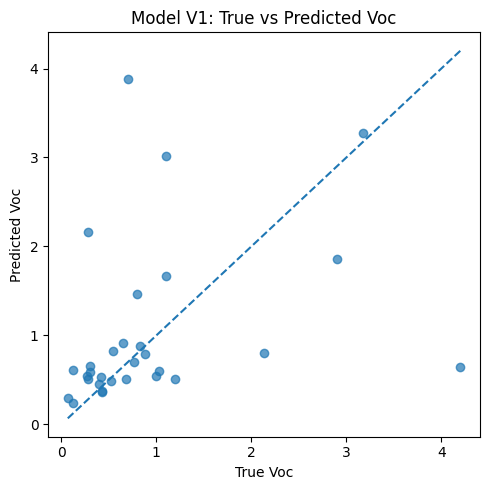

In [22]:
# Predicted vs true plot for Model V1
plt.figure(figsize=(5, 5))
plt.scatter(result_v1["y_test"], result_v1["y_pred"], alpha=0.7)
plt.xlabel("True Voc")
plt.ylabel("Predicted Voc")
plt.title("Model V1: True vs Predicted Voc")

min_val = min(result_v1["y_test"].min(), result_v1["y_pred"].min())
max_val = max(result_v1["y_test"].max(), result_v1["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

## Model V2

Target: `voc_V`  
Feature set: refined descriptors including ionic groups and electrode-related variables

In [23]:
result_v2 = run_rf_model(
    df_input=df_clean,
    features=features_v2,
    target="voc_V",
    model_name="Model V2"
)


===== Model V2 =====
Shape: (183, 114)
R2: -0.17003541464174976
RMSE: 0.5748534672846064
MAE: 0.43958420185520175
CV R2 mean: -0.1874694807248463


### V2 conclusion

Adding more detailed structure-, electrode-, and ion-related descriptors improves performance,
but `Voc` remains difficult to predict.

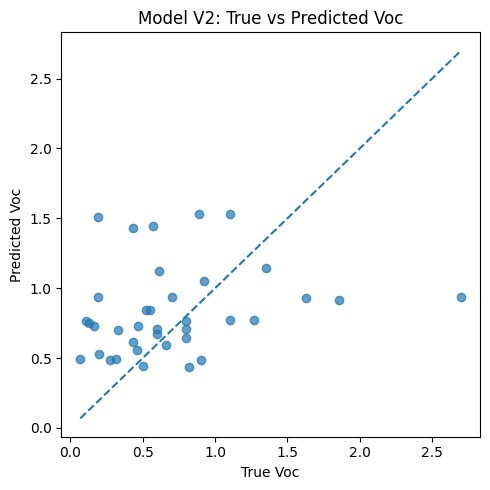

In [24]:
# Predicted vs true plot for Model V2
plt.figure(figsize=(5, 5))
plt.scatter(result_v2["y_test"], result_v2["y_pred"], alpha=0.7)
plt.xlabel("True Voc")
plt.ylabel("Predicted Voc")
plt.title("Model V2: True vs Predicted Voc")

min_val = min(result_v2["y_test"].min(), result_v2["y_pred"].min())
max_val = max(result_v2["y_test"].max(), result_v2["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

## Model V3

Target: `log_estimated_power_density`  
Feature set: same as V2

This model tests whether a derived target combining both voltage and current
is more learnable than `Voc` alone.

In [25]:
result_v3 = run_rf_model(
    df_input=df_clean,
    features=features_v2,
    target="log_estimated_power_density",
    model_name="Model V3"
)


===== Model V3 =====
Shape: (159, 106)
R2: 0.16896926930699052
RMSE: 1.2263726018794403
MAE: 0.9364530223087144
CV R2 mean: 0.20061902778926194


### V3 conclusion

Using `log_estimated_power_density` substantially improves learnability,
suggesting that this derived target is more aligned with the underlying device behavior.

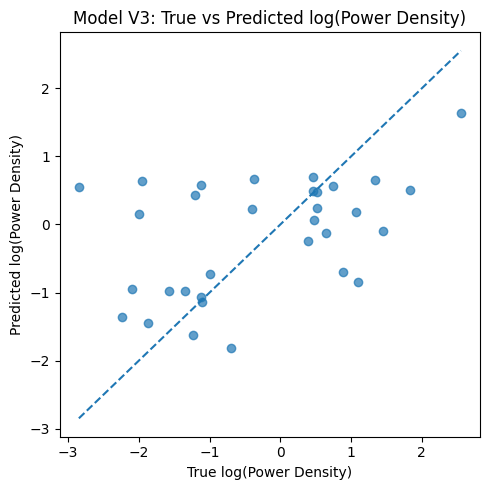

In [26]:
# Predicted vs true plot for Model V3
plt.figure(figsize=(5, 5))
plt.scatter(result_v3["y_test"], result_v3["y_pred"], alpha=0.7)
plt.xlabel("True log(Power Density)")
plt.ylabel("Predicted log(Power Density)")
plt.title("Model V3: True vs Predicted log(Power Density)")

min_val = min(result_v3["y_test"].min(), result_v3["y_pred"].min())
max_val = max(result_v3["y_test"].max(), result_v3["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

## Model V4

Target: `log_estimated_power_density`  
Feature set: V2 + `ion_type`

This model tests whether a physically grouped mobile-ion descriptor improves performance.

In [27]:
result_v4 = run_rf_model(
    df_input=df_clean,
    features=features_v4,
    target="log_estimated_power_density",
    model_name="Model V4"
)


===== Model V4 =====
Shape: (159, 109)
R2: 0.23395967561156017
RMSE: 1.1774425151964607
MAE: 0.8859266482717603
CV R2 mean: 0.21378045725393036


### V4 conclusion

Adding `ion_type` produces a modest but meaningful improvement,
indicating that ion transport regime contributes real physical signal.

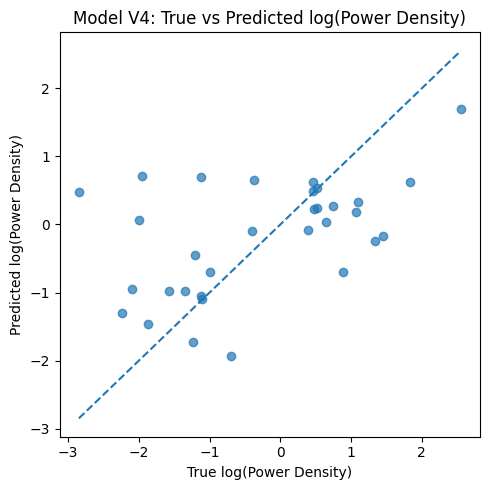

In [28]:
# Predicted vs true plot for Model V4
plt.figure(figsize=(5, 5))
plt.scatter(result_v4["y_test"], result_v4["y_pred"], alpha=0.7)
plt.xlabel("True log(Power Density)")
plt.ylabel("Predicted log(Power Density)")
plt.title("Model V4: True vs Predicted log(Power Density)")

min_val = min(result_v4["y_test"].min(), result_v4["y_pred"].min())
max_val = max(result_v4["y_test"].max(), result_v4["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

In [29]:
# Feature importance for Model V4
fi_v4 = pd.Series(
    result_v4["model"].feature_importances_,
    index=result_v4["X"].columns
).sort_values(ascending=False)

fi_v4.head(20)

ion_type_other_cation                            0.117078
structure_class_porous                           0.080599
dominant_mechanism_streaming                     0.055449
material_class_carbon                            0.045380
ionic_groups_carboxyl, hydroxyl                  0.039697
material_class_biomass                           0.030110
ionic_groups_carboxyl, hydroxyl, amino           0.029700
bottom_electrode_Au                              0.026666
electrode_symmetry                               0.025081
inorganic_electrolyte_present                    0.022846
bottom_electrode_Pt                              0.020799
metal_electrode                                  0.020314
water_interaction_mode_vapor_adsorption          0.019841
top_electrode_Pt                                 0.019693
ionic_groups_sulfonate                           0.019304
dominant_mechanism_ion_concentration_gradient    0.019155
device_structure_sandwich                        0.018305
water_interact

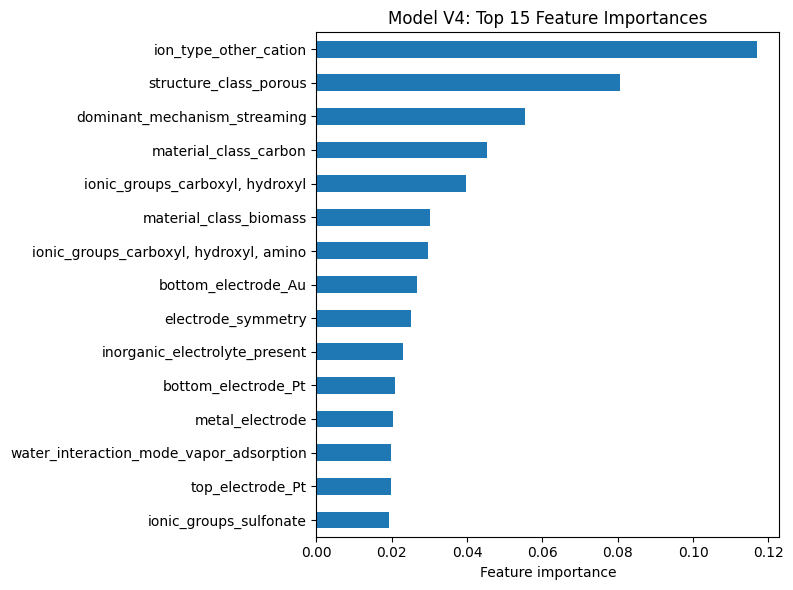

In [30]:
# Plot top 15 feature importances for Model V4
plt.figure(figsize=(8, 6))
fi_v4.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Model V4: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

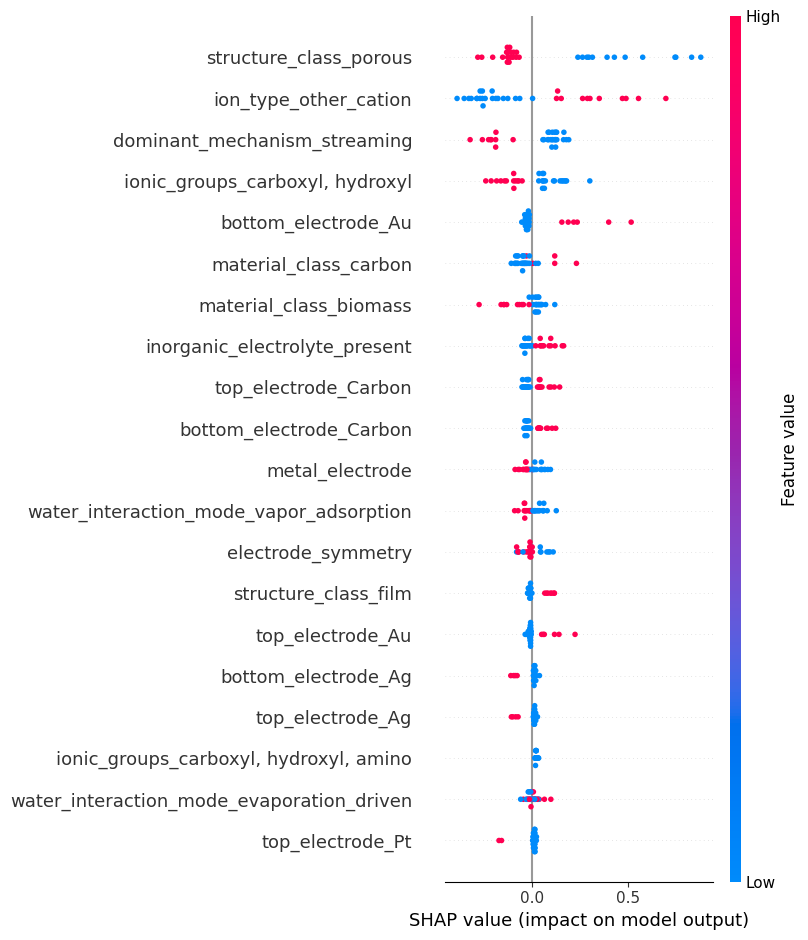

In [31]:
# SHAP summary plot for Model V4
explainer_v4 = shap.TreeExplainer(result_v4["model"])
shap_values_v4 = explainer_v4.shap_values(result_v4["X_test"])
shap.summary_plot(shap_values_v4, result_v4["X_test"])

## Model V5

Target: `log_estimated_power_density`  
Feature set: V4 + `device_structure`

This model tests whether device architecture adds predictive information
beyond structure-, ion-, and mechanism-related descriptors.

In [32]:
result_v5 = run_rf_model(
    df_input=df_clean,
    features=features_v5,
    target="log_estimated_power_density",
    model_name="Model V5"
)


===== Model V5 =====
Shape: (159, 118)
R2: 0.22727364714509424
RMSE: 1.1825697329162235
MAE: 0.888985086987722
CV R2 mean: 0.21051703273552524


### V5 conclusion

Adding `device_structure` yields only marginal improvement,
suggesting that apparent device-level differences are largely explained by
more fundamental structure- and mechanism-related variables.

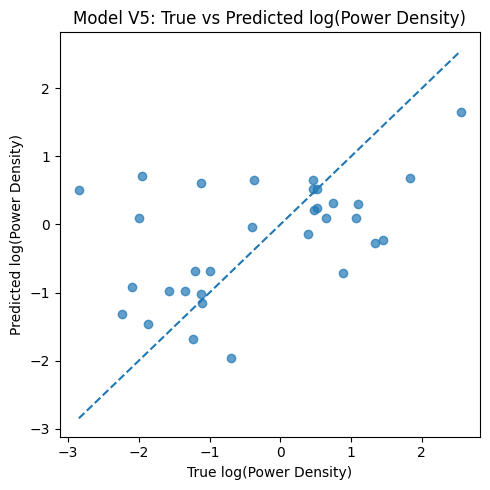

In [33]:
# Predicted vs true plot for Model V5
plt.figure(figsize=(5, 5))
plt.scatter(result_v5["y_test"], result_v5["y_pred"], alpha=0.7)
plt.xlabel("True log(Power Density)")
plt.ylabel("Predicted log(Power Density)")
plt.title("Model V5: True vs Predicted log(Power Density)")

min_val = min(result_v5["y_test"].min(), result_v5["y_pred"].min())
max_val = max(result_v5["y_test"].max(), result_v5["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

In [34]:
# Feature importance for Model V5
fi_v5 = pd.Series(
    result_v5["model"].feature_importances_,
    index=result_v5["X"].columns
).sort_values(ascending=False)

fi_v5.head(20)

ion_type_other_cation                            0.117364
structure_class_porous                           0.080905
dominant_mechanism_streaming                     0.054819
material_class_carbon                            0.044484
ionic_groups_carboxyl, hydroxyl                  0.039780
ionic_groups_carboxyl, hydroxyl, amino           0.029582
material_class_biomass                           0.028855
bottom_electrode_Au                              0.026823
electrode_symmetry                               0.023843
top_electrode_Pt                                 0.023093
inorganic_electrolyte_present                    0.022363
water_interaction_mode_vapor_adsorption          0.021829
metal_electrode                                  0.020006
ionic_groups_sulfonate                           0.018988
ionic_groups_carboxyl, imine                     0.018175
bottom_electrode_Pt                              0.018117
dominant_mechanism_ion_concentration_gradient    0.017748
top_electrode_

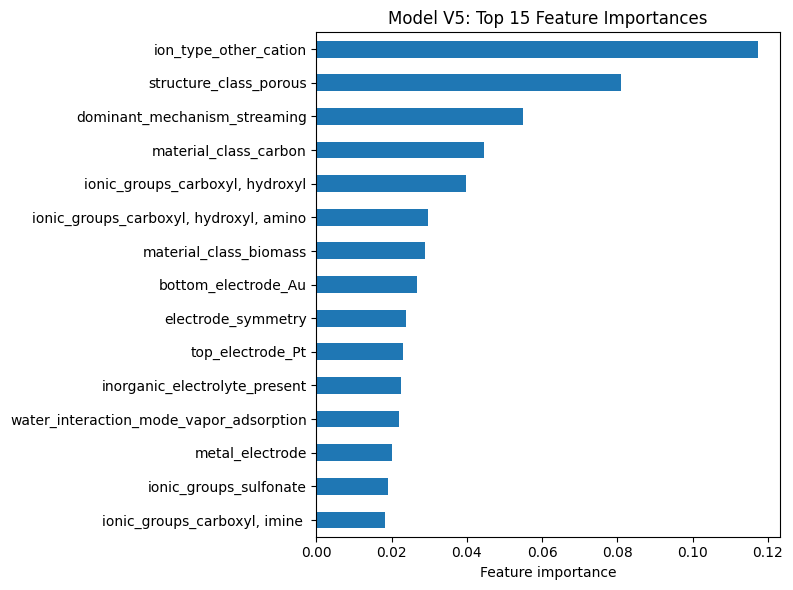

In [35]:
# Plot top 15 feature importances for Model V5
plt.figure(figsize=(8, 6))
fi_v5.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Model V5: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

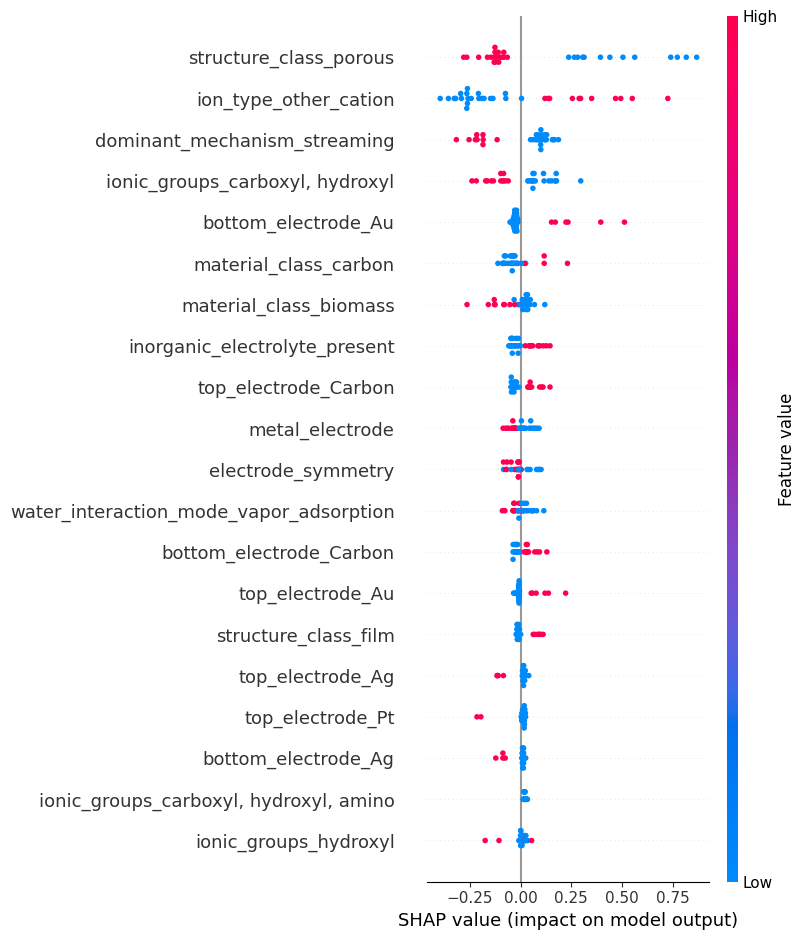

In [36]:
# SHAP summary plot for Model V5
explainer_v5 = shap.TreeExplainer(result_v5["model"])
shap_values_v5 = explainer_v5.shap_values(result_v5["X_test"])
shap.summary_plot(shap_values_v5, result_v5["X_test"])

## Model comparison summary

In [37]:
model_summary = pd.DataFrame({
    "Model": ["V1", "V2", "V3", "V4", "V5"],
    "Target": [
        "voc_V",
        "voc_V",
        "log_estimated_power_density",
        "log_estimated_power_density",
        "log_estimated_power_density"
    ],
    "Num_features_after_encoding": [
        result_v1["X"].shape[1],
        result_v2["X"].shape[1],
        result_v3["X"].shape[1],
        result_v4["X"].shape[1],
        result_v5["X"].shape[1]
    ],
    "R2": [
        result_v1["r2"],
        result_v2["r2"],
        result_v3["r2"],
        result_v4["r2"],
        result_v5["r2"]
    ],
    "RMSE": [
        result_v1["rmse"],
        result_v2["rmse"],
        result_v3["rmse"],
        result_v4["rmse"],
        result_v5["rmse"]
    ],
    "MAE": [
        result_v1["mae"],
        result_v2["mae"],
        result_v3["mae"],
        result_v4["mae"],
        result_v5["mae"]
    ],
    "CV_R2_mean": [
        result_v1["cv_scores"].mean(),
        result_v2["cv_scores"].mean(),
        result_v3["cv_scores"].mean(),
        result_v4["cv_scores"].mean(),
        result_v5["cv_scores"].mean()
    ]
})

model_summary

,Model,Target,Num_features_after_encoding,R2,RMSE,MAE,CV_R2_mean
0,V1,voc_V,29,-0.312892,1.085642,0.634098,-0.163902
1,V2,voc_V,114,-0.170035,0.574853,0.439584,-0.187469
2,V3,log_estimated_power_density,106,0.168969,1.226373,0.936453,0.200619
3,V4,log_estimated_power_density,109,0.233960,1.177443,0.885927,0.213780
4,V5,log_estimated_power_density,118,0.227274,1.182570,0.888985,0.210517


## Mechanism diagnosis

This section examines whether model-identified signals are consistent with grouped statistical patterns.

In [38]:
pd.crosstab(df_analysis["ion_type"], df_analysis["dominant_mechanism"])

dominant_mechanism,ion_concentration_gradient,ion_concentration_gradient + pyroelectricity,ion_concentration_gradient + radiative_cooling_enhanced_evaporation,ion_concentration_gradient + schottky_junction,ion_concentration_gradient + thermo_diffusion,streaming
ion_type,,,,,,
anion,3,0,0,0,0,6
other_cation,51,0,1,0,2,0
proton,46,1,0,1,2,46


In [39]:
df_analysis.groupby("mechanism_simple")["log_estimated_power_density"].describe()

,count,mean,std,min,25%,50%,75%,max
mechanism_simple,,,,,,,,
ion_gradient,107.0,-0.050499,1.337760,-4.283997,-0.888192,0.209113,0.787230,2.916454
streaming,52.0,-1.058450,1.010037,-3.217527,-1.585934,-1.113544,-0.674957,1.611192


In [40]:
df_analysis.groupby("ion_type")["log_estimated_power_density"].describe()

,count,mean,std,min,25%,50%,75%,max
ion_type,,,,,,,,
anion,9.0,-0.913929,1.259299,-2.698753,-2.027982,-0.699674,-0.336204,1.343409
other_cation,54.0,0.344277,0.971853,-2.606249,0.037254,0.456742,0.827928,2.916454
proton,96.0,-0.737587,1.343074,-4.283997,-1.524175,-0.974420,0.227641,2.552060


In [41]:
df_analysis.groupby(["ion_type", "dominant_mechanism"])["log_estimated_power_density"].mean().sort_values(ascending=False)

ion_type      dominant_mechanism                                                 
other_cation  ion_concentration_gradient + radiative_cooling_enhanced_evaporation    1.828144
              ion_concentration_gradient + thermo_diffusion                          1.470624
proton        ion_concentration_gradient + pyroelectricity                           0.685361
other_cation  ion_concentration_gradient                                             0.271011
anion         ion_concentration_gradient                                             0.101715
proton        ion_concentration_gradient                                            -0.498249
              ion_concentration_gradient + thermo_diffusion                         -0.620746
              ion_concentration_gradient + schottky_junction                        -0.823906
              streaming                                                             -1.011062
anion         streaming                                                 

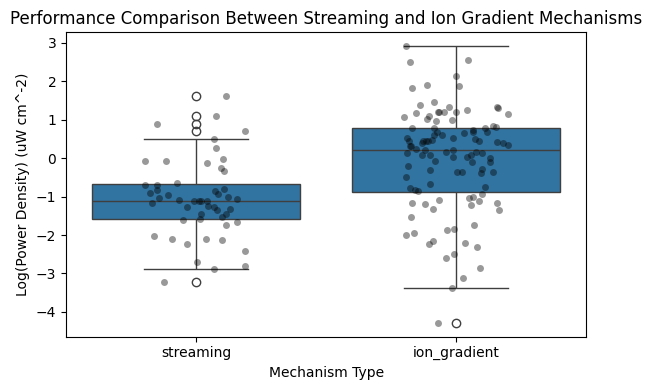

In [42]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_analysis,
    x="mechanism_simple",
    y="log_estimated_power_density"
)

sns.stripplot(
    data=df_analysis,
    x="mechanism_simple",
    y="log_estimated_power_density",
    color="black",
    alpha=0.4,
    jitter=0.2
)

plt.ylabel("Log(Power Density) (uW cm^-2)")
plt.xlabel("Mechanism Type")
plt.title("Performance Comparison Between Streaming and Ion Gradient Mechanisms")
plt.tight_layout()
plt.show()

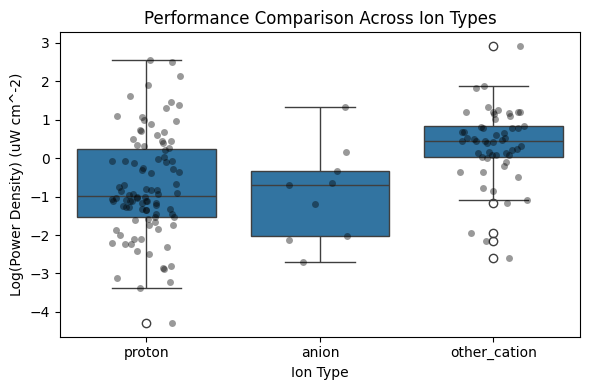

In [43]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_analysis,
    x="ion_type",
    y="log_estimated_power_density"
)

sns.stripplot(
    data=df_analysis,
    x="ion_type",
    y="log_estimated_power_density",
    color="black",
    alpha=0.4,
    jitter=0.2
)

plt.ylabel("Log(Power Density) (uW cm^-2)")
plt.xlabel("Ion Type")
plt.title("Performance Comparison Across Ion Types")
plt.tight_layout()
plt.show()

## Polyelectrolyte confounding diagnosis

In [44]:
pd.crosstab(df_analysis["polyelectrolyte_present"], df_analysis["dominant_mechanism"])

dominant_mechanism,ion_concentration_gradient,ion_concentration_gradient + pyroelectricity,ion_concentration_gradient + radiative_cooling_enhanced_evaporation,ion_concentration_gradient + schottky_junction,ion_concentration_gradient + thermo_diffusion,streaming
polyelectrolyte_present,,,,,,
0,54,0,1,0,2,42
1,46,1,0,1,2,10


In [45]:
for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(pd.crosstab(df_analysis[col], df_analysis["ion_type"]))


 polyelectrolyte_present
ion_type                 anion  other_cation  proton
polyelectrolyte_present                             
0                            7            39      53
1                            2            15      43

 has_anionic
ion_type     anion  other_cation  proton
has_anionic                             
0                7            39      68
1                2            15      28

 has_cationic
ion_type      anion  other_cation  proton
has_cationic                             
0                 8            52      83
1                 1             2      13

 has_zwitterionic
ion_type          anion  other_cation  proton
has_zwitterionic                             
0                     9            54      86
1                     0             0      10


In [46]:
for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(df_analysis.groupby(col)["log_estimated_power_density"].describe())


 polyelectrolyte_present
                         count      mean       std       min       25%  \
polyelectrolyte_present                                                  
0                         99.0 -0.461958  1.326897 -4.283997 -1.341851   
1                         60.0 -0.245149  1.321135 -3.384971 -1.060233   

                              50%       75%       max  
polyelectrolyte_present                                
0                       -0.362509  0.486479  2.916454  
1                       -0.082444  0.699506  2.552060  

 has_anionic
             count      mean       std       min       25%       50%  \
has_anionic                                                            
0            114.0 -0.505340  1.290823 -4.283997 -1.337130 -0.564766   
1             45.0 -0.062977  1.370816 -3.384971 -0.924449  0.163944   

                  75%       max  
has_anionic                      
0            0.457690  2.916454  
1            0.787354  2.552060  

 has_cationic

In [47]:
df_ig = df_analysis[df_analysis["mechanism_simple"] == "ion_gradient"].copy()

for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(df_ig.groupby(col)["log_estimated_power_density"].describe())


 polyelectrolyte_present
                         count      mean       std       min       25%  \
polyelectrolyte_present                                                  
0                         57.0 -0.051695  1.367019 -4.283997 -0.775983   
1                         50.0 -0.049136  1.317450 -3.384971 -0.981109   

                              50%       75%       max  
polyelectrolyte_present                                
0                        0.209113  0.773238  2.916454  
1                        0.207258  0.930131  2.552060  

 has_anionic
             count      mean       std       min       25%       50%  \
has_anionic                                                            
0             65.0 -0.120176  1.361237 -4.283997 -1.097448  0.160619   
1             42.0  0.057335  1.309477 -3.384971 -0.804111  0.283062   

                  75%       max  
has_anionic                      
0            0.773238  2.916454  
1            0.930131  2.552060  

 has_cationic

In [48]:
df_oc = df_analysis[df_analysis["ion_type"] == "other_cation"].copy()

for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(df_oc.groupby(col)["log_estimated_power_density"].describe())


 polyelectrolyte_present
                         count      mean       std       min       25%  \
polyelectrolyte_present                                                  
0                         39.0  0.341205  0.998216 -2.606249 -0.045180   
1                         15.0  0.352264  0.933217 -2.167427  0.164877   

                              50%       75%       max  
polyelectrolyte_present                                
0                        0.454845  0.826552  2.916454  
1                        0.513098  0.942132  1.342423  

 has_anionic
             count      mean       std       min       25%       50%  \
has_anionic                                                            
0             39.0  0.341205  0.998216 -2.606249 -0.045180  0.454845   
1             15.0  0.352264  0.933217 -2.167427  0.164877  0.513098   

                  75%       max  
has_anionic                      
0            0.826552  2.916454  
1            0.942132  1.342423  

 has_cationic

### Polyelectrolyte conclusion

Polyelectrolyte-related features show weak and context-dependent effects.
They are not dominant global predictors and appear to be secondary to mechanism-level descriptors.

## Device structure diagnosis

In [49]:
pd.crosstab(df_analysis["device_structure"], df_analysis["dominant_mechanism"])

dominant_mechanism,ion_concentration_gradient,ion_concentration_gradient + pyroelectricity,ion_concentration_gradient + radiative_cooling_enhanced_evaporation,ion_concentration_gradient + schottky_junction,ion_concentration_gradient + thermo_diffusion,streaming
device_structure,,,,,,
coaxial_cable,2,0,0,0,0,0
in-plane,32,1,0,0,2,45
sandwich,66,0,1,1,2,7


In [50]:
pd.crosstab(df_analysis["device_structure"], df_analysis["ion_type"])

ion_type,anion,other_cation,proton
device_structure,,,
coaxial_cable,0,0,2
in-plane,6,26,48
sandwich,3,28,46


In [51]:
df_analysis.groupby("device_structure")["log_estimated_power_density"].describe()

,count,mean,std,min,25%,50%,75%,max
device_structure,,,,,,,,
coaxial_cable,2.0,-0.180547,1.638042,-1.338817,-0.759682,-0.180547,0.398588,0.977724
in-plane,80.0,-0.598952,1.246535,-4.283997,-1.336961,-0.737828,0.353553,2.916454
sandwich,77.0,-0.157994,1.377124,-3.384971,-1.124933,0.079182,0.787354,2.552060


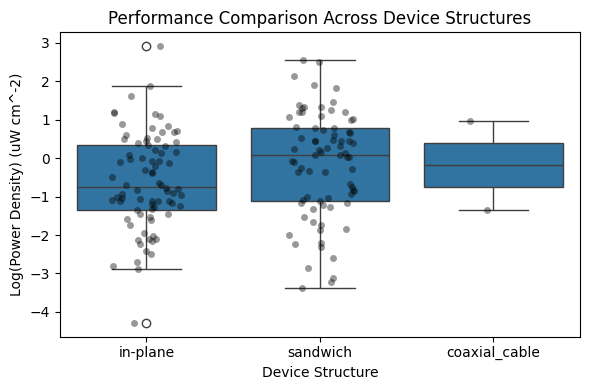

In [52]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_analysis,
    x="device_structure",
    y="log_estimated_power_density"
)

sns.stripplot(
    data=df_analysis,
    x="device_structure",
    y="log_estimated_power_density",
    color="black",
    alpha=0.4,
    jitter=0.2
)

plt.ylabel("Log(Power Density) (uW cm^-2)")
plt.xlabel("Device Structure")
plt.title("Performance Comparison Across Device Structures")
plt.tight_layout()
plt.show()

### Device structure conclusion

Device structure shows apparent statistical differences,
but it does not emerge as an independent predictive factor once mechanism- and transport-related descriptors are included.

## Asymmetry-origin diagnosis

In [53]:
for col in ["asym_env", "asym_chem", "asym_electrode"]:
    print("\n", col)
    print(df_analysis.groupby(col)["log_estimated_power_density"].describe())


 asym_env
          count      mean       std       min       25%       50%       75%  \
asym_env                                                                      
0          62.0 -0.124924  1.315486 -4.283997 -0.955973  0.119900  0.765413   
1          97.0 -0.543273  1.311402 -3.384971 -1.351630 -0.805067  0.493807   

               max  
asym_env            
0         2.552060  
1         2.916454  

 asym_chem
           count      mean       std       min       25%       50%       75%  \
asym_chem                                                                      
0           91.0 -0.642703  1.271012 -3.217527 -1.453472 -0.948844  0.414587   
1           68.0 -0.028777  1.322695 -4.283997 -0.535867  0.162281  0.776705   

                max  
asym_chem            
0          2.916454  
1          2.552060  

 asym_electrode
                count      mean       std       min       25%       50%  \
asym_electrode                                                            


In [54]:
for col in ["asym_env", "asym_chem", "asym_electrode"]:
    print("\n", col)
    print(pd.crosstab(df_analysis[col], df_analysis["dominant_mechanism"]))


 asym_env
dominant_mechanism  ion_concentration_gradient  \
asym_env                                         
0                                           60   
1                                           40   

dominant_mechanism  ion_concentration_gradient + pyroelectricity  \
asym_env                                                           
0                                                              0   
1                                                              1   

dominant_mechanism  ion_concentration_gradient + radiative_cooling_enhanced_evaporation  \
asym_env                                                                                  
0                                                                   0                     
1                                                                   1                     

dominant_mechanism  ion_concentration_gradient + schottky_junction  \
asym_env                                                             
0         

In [55]:
for col in ["asym_env", "asym_chem", "asym_electrode"]:
    print("\n", col)
    print(pd.crosstab(df_analysis[col], df_analysis["ion_type"]))


 asym_env
ion_type  anion  other_cation  proton
asym_env                             
0             1            23      38
1             8            31      58

 asym_chem
ion_type   anion  other_cation  proton
asym_chem                             
0              5            22      64
1              4            32      32

 asym_electrode
ion_type        anion  other_cation  proton
asym_electrode                             
0                   7            41      69
1                   2            13      27


In [56]:
for col in ["asym_env", "asym_chem", "asym_electrode"]:
    print("\n", col)
    print(df_ig.groupby(col)["log_estimated_power_density"].describe())


 asym_env
          count      mean       std       min       25%       50%       75%  \
asym_env                                                                      
0          61.0 -0.124923  1.326403 -4.283997 -0.999996  0.160619  0.773238   
1          46.0  0.048194  1.360972 -3.384971 -0.738436  0.340968  1.109053   

               max  
asym_env            
0         2.552060  
1         2.916454  

 asym_chem
           count     mean       std       min       25%       50%       75%  \
asym_chem                                                                     
0           45.0 -0.22334  1.358001 -2.847406 -1.230985  0.130334  0.685361   
1           62.0  0.07495  1.319676 -4.283997 -0.371610  0.310988  0.787292   

                max  
asym_chem            
0          2.916454  
1          2.552060  

 asym_electrode
                count      mean       std       min       25%       50%  \
asym_electrode                                                            
0   

## Model V6

Target: `log_estimated_power_density`  
Feature set: V4 + asymmetry decomposition (`asym_env`, `asym_chem`, `asym_electrode`)

In [57]:
result_v6 = run_rf_model(
    df_input=df_clean,
    features=features_v6,
    target="log_estimated_power_density",
    model_name="Model V6"
)


===== Model V6 =====
Shape: (159, 112)
R2: 0.2971952241971503
RMSE: 1.1277978168313836
MAE: 0.8655304082167458
CV R2 mean: 0.20581067487066926


In [58]:
fi_v6 = pd.Series(
    result_v6["model"].feature_importances_,
    index=result_v6["X"].columns
).sort_values(ascending=False)

fi_v6.head(20)

ion_type_other_cation                        0.115032
structure_class_porous                       0.079046
dominant_mechanism_streaming                 0.052093
material_class_carbon                        0.040723
ionic_groups_carboxyl, hydroxyl              0.037246
ionic_groups_carboxyl, hydroxyl, amino       0.030053
material_class_biomass                       0.026881
bottom_electrode_Au                          0.026072
asym_chem                                    0.024151
inorganic_electrolyte_present                0.023572
top_electrode_Pt                             0.023437
electrode_symmetry                           0.019243
ionic_groups_carboxyl, imine                 0.018783
metal_electrode                              0.018467
asym_env                                     0.018315
water_interaction_mode_vapor_adsorption      0.017486
water_interaction_mode_evaporation_driven    0.017407
bottom_electrode_Pt                          0.017292
ionic_groups_sulfonate      

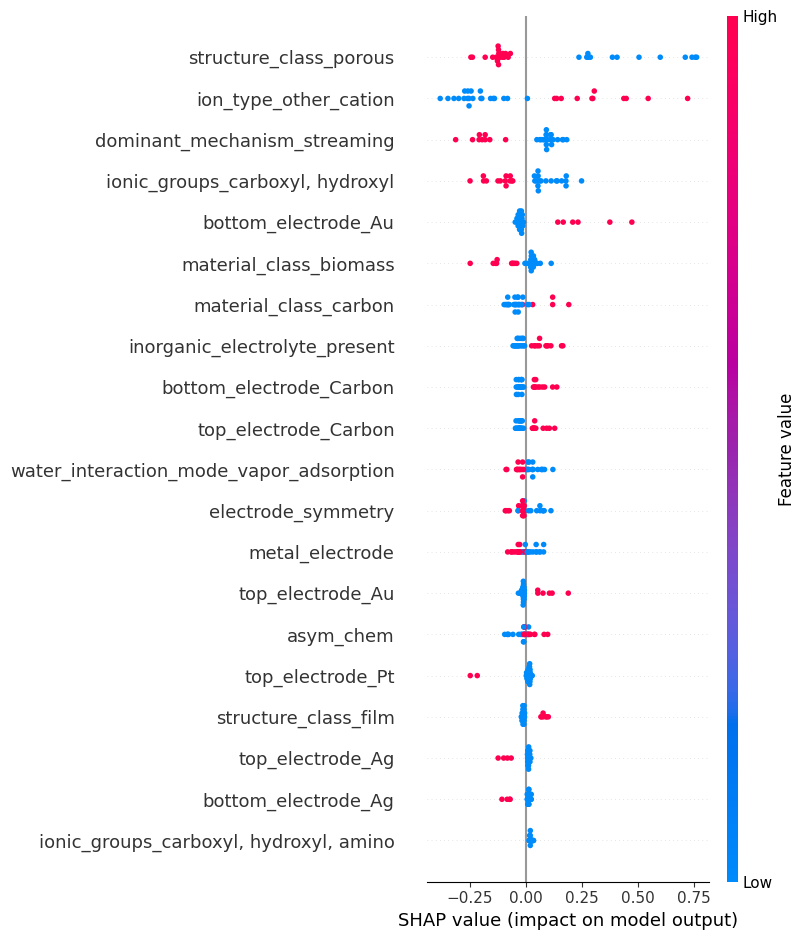

In [59]:
explainer_v6 = shap.TreeExplainer(result_v6["model"])
shap_values_v6 = explainer_v6.shap_values(result_v6["X_test"])
shap.summary_plot(shap_values_v6, result_v6["X_test"])

### V6 conclusion

This model evaluates whether decomposed asymmetry sources provide independent mechanism-level information beyond ion type and dominant mechanism.

## Ion-origin diagnosis

In [60]:
for col in ["ion_from_material", "ion_from_electrolyte", "ion_from_water"]:
    print("\n", col)
    print(df_analysis.groupby(col)["log_estimated_power_density"].describe())


 ion_from_material
                   count      mean       std       min       25%       50%  \
ion_from_material                                                            
0                   67.0 -0.045342  1.182093 -2.879097 -0.737828  0.160619   
1                   92.0 -0.623966  1.375111 -4.283997 -1.477957 -0.880132   

                        75%       max  
ion_from_material                      
0                  0.672721  2.916454  
1                  0.407919  2.552060  

 ion_from_electrolyte
                      count      mean       std       min       25%       50%  \
ion_from_electrolyte                                                            
0                     102.0 -0.737748  1.339791 -4.283997 -1.526796 -0.974420   
1                      57.0  0.259782  1.031593 -2.606249 -0.103198  0.431364   

                          75%       max  
ion_from_electrolyte                     
0                     0.22341  2.552060  
1                     0.82380  2.

In [61]:
for col in ["ion_from_material", "ion_from_electrolyte", "ion_from_water"]:
    print("\n", col)
    print(pd.crosstab(df_analysis[col], df_analysis["dominant_mechanism"]))


 ion_from_material
dominant_mechanism  ion_concentration_gradient  \
ion_from_material                                
0                                           48   
1                                           52   

dominant_mechanism  ion_concentration_gradient + pyroelectricity  \
ion_from_material                                                  
0                                                              0   
1                                                              1   

dominant_mechanism  ion_concentration_gradient + radiative_cooling_enhanced_evaporation  \
ion_from_material                                                                         
0                                                                   1                     
1                                                                   0                     

dominant_mechanism  ion_concentration_gradient + schottky_junction  \
ion_from_material                                                    
0

In [62]:
for col in ["ion_from_material", "ion_from_electrolyte", "ion_from_water"]:
    print("\n", col)
    print(pd.crosstab(df_analysis[col], df_analysis["ion_type"]))


 ion_from_material
ion_type           anion  other_cation  proton
ion_from_material                             
0                      8            48      11
1                      1             6      85

 ion_from_electrolyte
ion_type              anion  other_cation  proton
ion_from_electrolyte                             
0                         6             4      92
1                         3            50       4

 ion_from_water
ion_type        anion  other_cation  proton
ion_from_water                             
0                   3            54      86
1                   6             0      10


### Ion-origin conclusion

Ion-origin variables are physically meaningful but are likely to be strongly entangled with dominant mechanism and ion-type descriptors.
Their independent value should be assessed cautiously.

## Phase 1 summary

Main findings:
- The derived target `log_estimated_power_density` is substantially more learnable than `Voc`.
- Ion transport regime is the strongest determinant of performance.
- Ion-gradient systems outperform streaming systems.
- `ion_type` provides meaningful additional signal.
- Polyelectrolyte-related features are weak and context-dependent.
- Device structure shows apparent differences but limited independent predictive value.
- Further refinement should focus on mechanism-linked variables rather than simply adding more labels.

In [63]:
model_summary = pd.concat([
    model_summary,
    pd.DataFrame({
        "Model": ["V6"],
        "Target": ["log_estimated_power_density"],
        "Num_features_after_encoding": [result_v6["X"].shape[1]],
        "R2": [result_v6["r2"]],
        "RMSE": [result_v6["rmse"]],
        "MAE": [result_v6["mae"]],
        "CV_R2_mean": [result_v6["cv_scores"].mean()]
    })
], ignore_index=True)

model_summary

,Model,Target,Num_features_after_encoding,R2,RMSE,MAE,CV_R2_mean
0,V1,voc_V,29,-0.312892,1.085642,0.634098,-0.163902
1,V2,voc_V,114,-0.170035,0.574853,0.439584,-0.187469
2,V3,log_estimated_power_density,106,0.168969,1.226373,0.936453,0.200619
3,V4,log_estimated_power_density,109,0.233960,1.177443,0.885927,0.213780
4,V5,log_estimated_power_density,118,0.227274,1.182570,0.888985,0.210517
5,V6,log_estimated_power_density,112,0.297195,1.127798,0.865530,0.205811


In [64]:
df_clean.to_csv("hydrovoltaic_clean_phase1.csv", index=False)